<a href="https://www.kaggle.com/code/sonawanelalitsunil/fraud-detection-dataset-ml-99-99?scriptVersionId=235263796" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fraud-detection-dataset/AIML Dataset.csv


## Title: Fraud Detection Dataset

#### Description: A dataset containing transactional and user behavior data used to identify and predict fraudulent activities in financial systems. Suitable for machine learning and anomaly detection tasks.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/fraud-detection-dataset/AIML Dataset.csv')

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [10]:
df.shape

(6362620, 11)

In [11]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

## Data visualizations

In [12]:
# Basic setup
sns.set(style="whitegrid")
plt.style.use('ggplot')

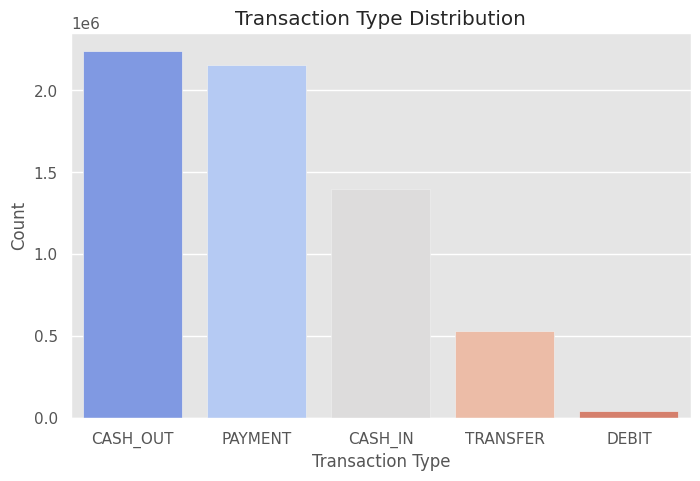

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='type', order=df['type'].value_counts().index, palette='coolwarm')
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()


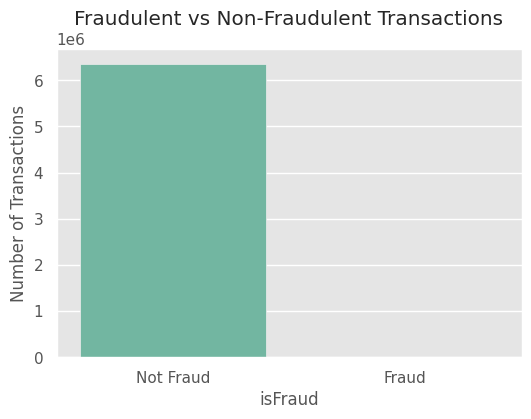

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df, palette='Set2')
plt.title('Fraudulent vs Non-Fraudulent Transactions')
plt.xticks([0,1], ['Not Fraud', 'Fraud'])
plt.ylabel('Number of Transactions')
plt.show()


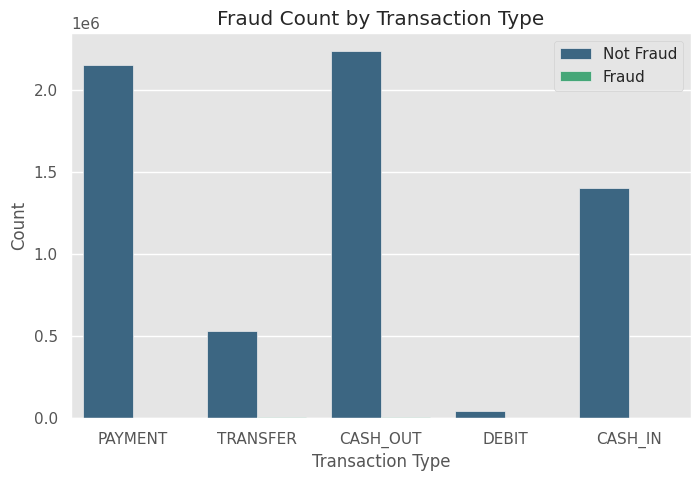

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='type', hue='isFraud', data=df, palette='viridis')
plt.title('Fraud Count by Transaction Type')
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.legend(['Not Fraud', 'Fraud'])
plt.show()


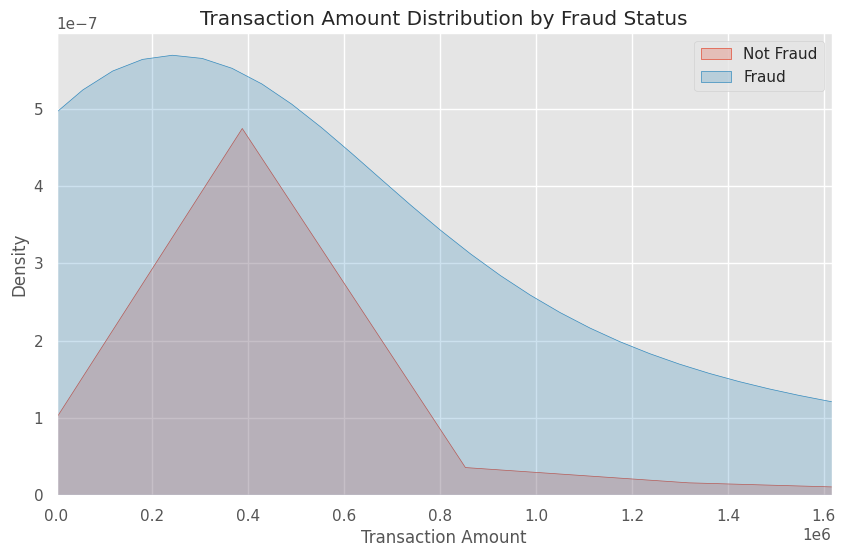

In [16]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df[df['isFraud'] == 0]['amount'], label='Not Fraud', fill=True)
sns.kdeplot(data=df[df['isFraud'] == 1]['amount'], label='Fraud', fill=True)
plt.xlim(0, df['amount'].quantile(0.99))  # remove outliers
plt.title('Transaction Amount Distribution by Fraud Status')
plt.xlabel('Transaction Amount')
plt.legend()
plt.show()


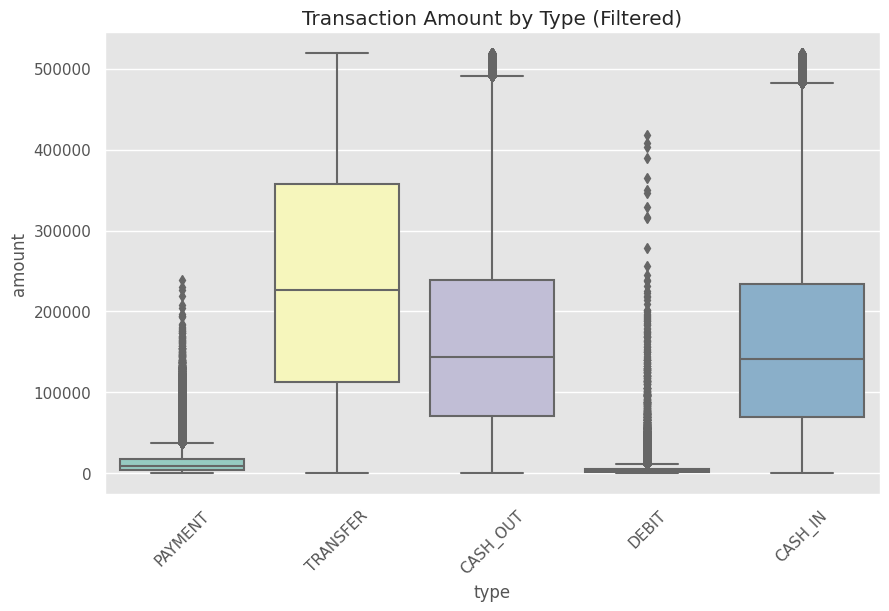

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(x='type', y='amount', data=df[df['amount'] < df['amount'].quantile(0.95)], palette='Set3')
plt.title('Transaction Amount by Type (Filtered)')
plt.xticks(rotation=45)
plt.show()


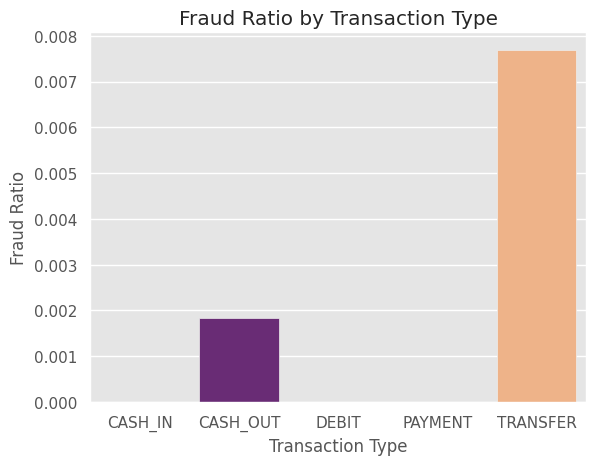

In [18]:
fraud_ratio = df.groupby('type')['isFraud'].mean().reset_index()
sns.barplot(x='type', y='isFraud', data=fraud_ratio, palette='magma')
plt.title('Fraud Ratio by Transaction Type')
plt.ylabel('Fraud Ratio')
plt.xlabel('Transaction Type')
plt.show()


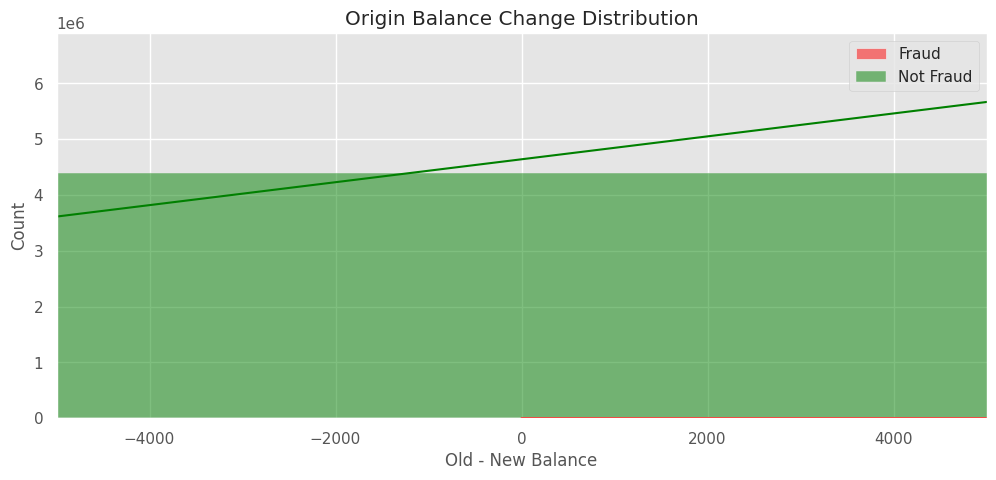

In [19]:
df['origin_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['dest_diff'] = df['newbalanceDest'] - df['oldbalanceDest']

plt.figure(figsize=(12,5))
sns.histplot(df[df['isFraud']==1]['origin_diff'], color='red', bins=100, label='Fraud', kde=True)
sns.histplot(df[df['isFraud']==0]['origin_diff'], color='green', bins=100, label='Not Fraud', kde=True)
plt.xlim(-5000, 5000)
plt.legend()
plt.title('Origin Balance Change Distribution')
plt.xlabel('Old - New Balance')
plt.show()


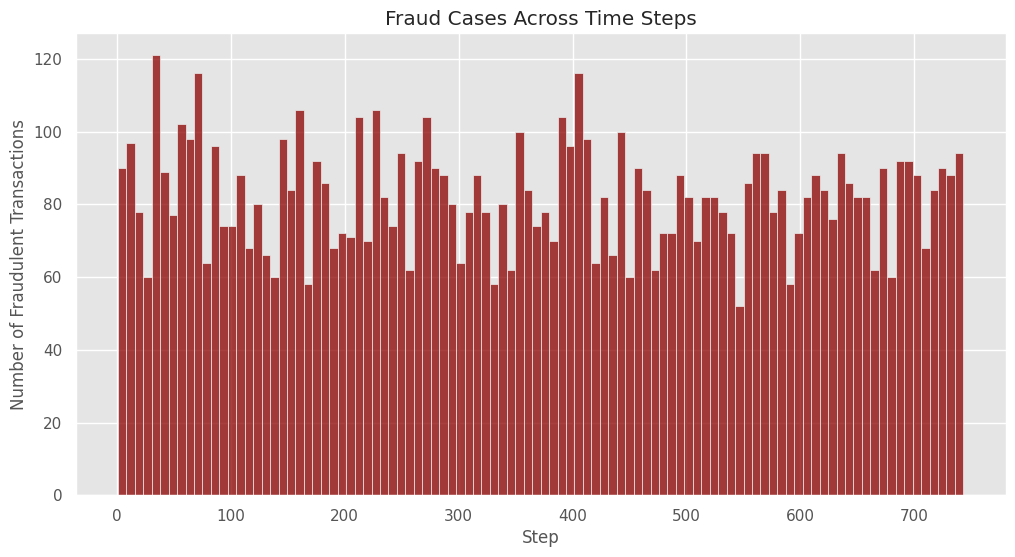

In [20]:
plt.figure(figsize=(12,6))
sns.histplot(data=df[df['isFraud']==1], x='step', bins=100, color='darkred')
plt.title('Fraud Cases Across Time Steps')
plt.xlabel('Step')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()


In [21]:
import plotly.express as px

In [22]:
fig = px.scatter(df[df['isFraud']==1], x='amount', y='step', color='type',
                 title='Fraudulent Transactions by Amount and Time Step',
                 hover_data=['nameOrig', 'nameDest'])
fig.show()


## Predictive modeling

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [24]:
# Drop nameOrig and nameDest (IDs, not useful for ML)
df = df.drop(['nameOrig', 'nameDest'], axis=1)

# Label encode the 'type' column
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])  # e.g., 'TRANSFER' => 4

# Features & target
X = df.drop('isFraud', axis=1)
y = df['isFraud']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [26]:
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"{name} Accuracy: {acc*100:.2f}%")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Fraud", "Fraud"])
    disp.plot(cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


Logistic Regression Accuracy: 99.82%


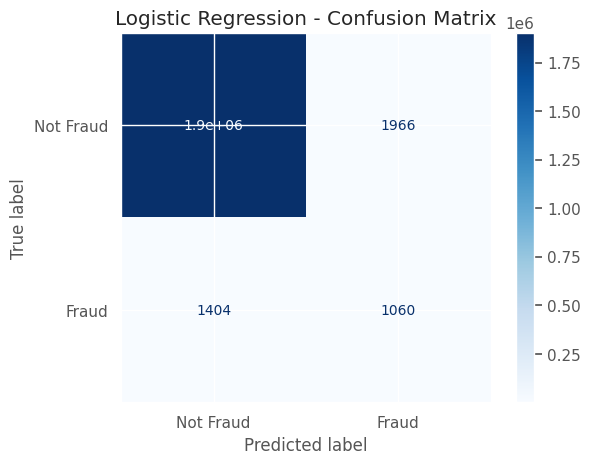

Decision Tree Accuracy: 99.97%


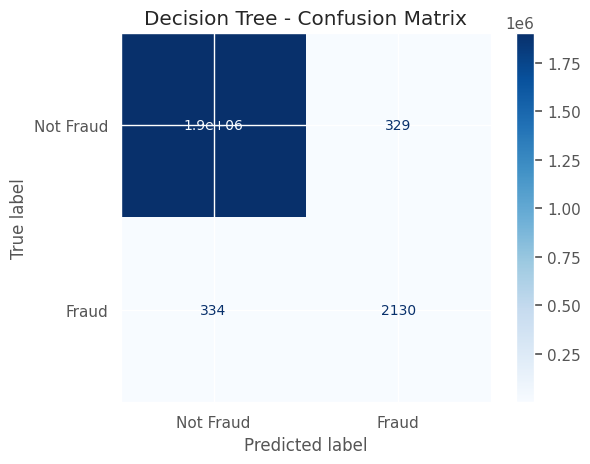

Random Forest Accuracy: 99.97%


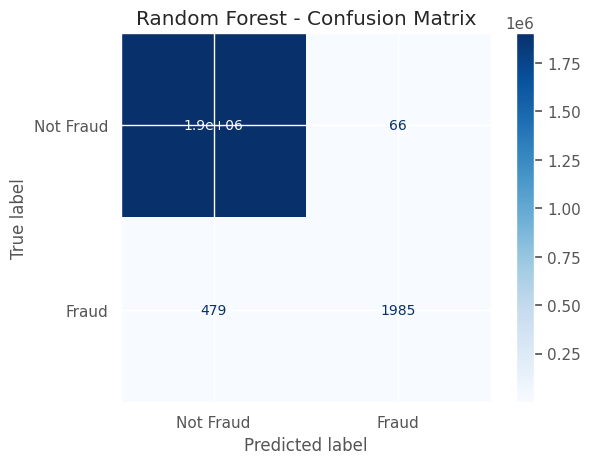

Support Vector Machine Accuracy: 99.92%


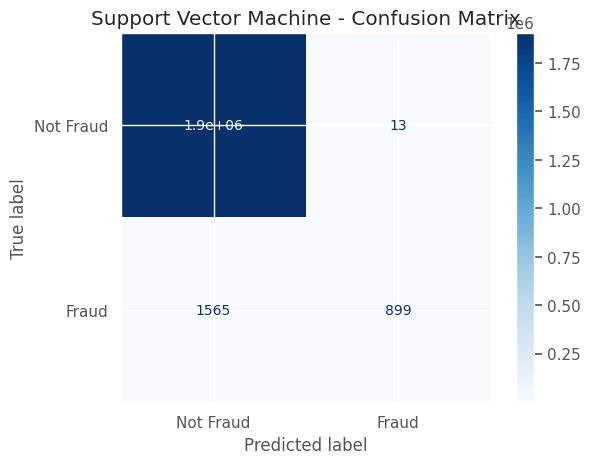

K-Nearest Neighbors Accuracy: 99.95%


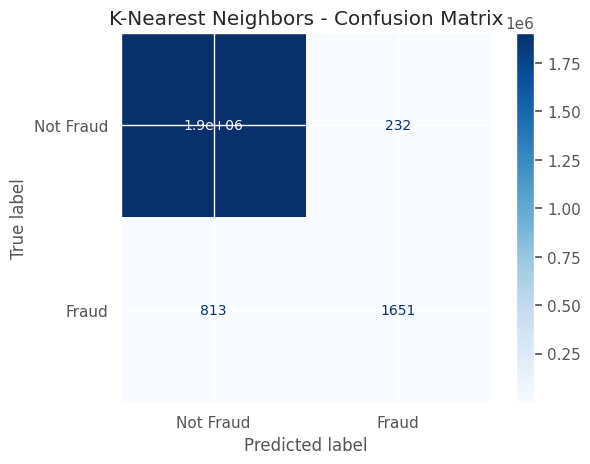

Naive Bayes Accuracy: 99.04%


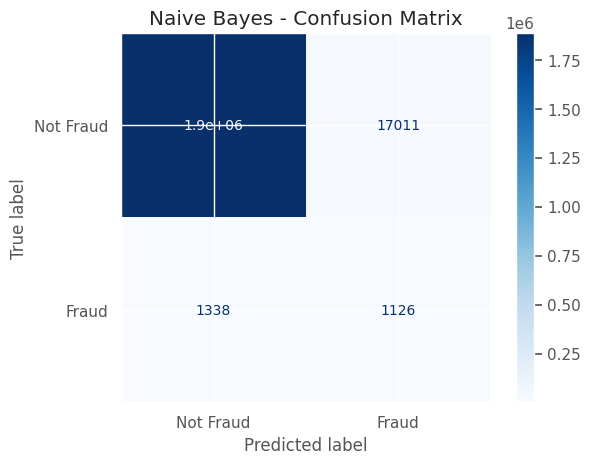

In [27]:
models = [
    (LogisticRegression(max_iter=1000), "Logistic Regression"),
    (DecisionTreeClassifier(), "Decision Tree"),
    (RandomForestClassifier(), "Random Forest"),
    (SVC(kernel='rbf'), "Support Vector Machine"),
    (KNeighborsClassifier(), "K-Nearest Neighbors"),
    (GaussianNB(), "Naive Bayes")
]

for model, name in models:
    evaluate_model(model, name)


## Thank you..pls upvote!!!!